In [4]:
import os 
import cv2
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from skimage.transform import resize

In [38]:
def extract_features(image): 
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hog = cv2.HOGDescriptor()
    features = hog.compute(gray)
    return features.flatten()

In [30]:
def load_images_from_directory(directory):
    images = []
    labels = []
    class_names = []
    for root,dirs,files, in os.walk(directory):
        for class_name in dirs:
            class_dir = os.path.join(root, class_name)
            for filename in os.listdir(class_dir):
                img_path = os.path.join(class_dir, filename)
                image = cv2.imread(img_path)
                if image is not None:
                    images.append(image)
                    labels.append(class_name)
                    class_names.append(class_name)
    return images, labels, class_names

In [27]:
def visualize_class_distribution(labels, class_names):
    class_counts = {class_name: labels.count(class_name) for class_name in set(class_names)}
    plt.bar(class_counts.keys(), class_counts.values())
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.title('Class Distribution')
    plt.show()
    total_samples = sum(class_counts.values())
    for class_name, count in class_counts.items():
        percentage = (count / total_samples) * 100
        print(f'{class_name}: {count} samples ({percentage:.2f}%)')

In [33]:
directory = 'dataset200/train'

In [35]:
images, labels, class_names = load_images_from_directory(directory)

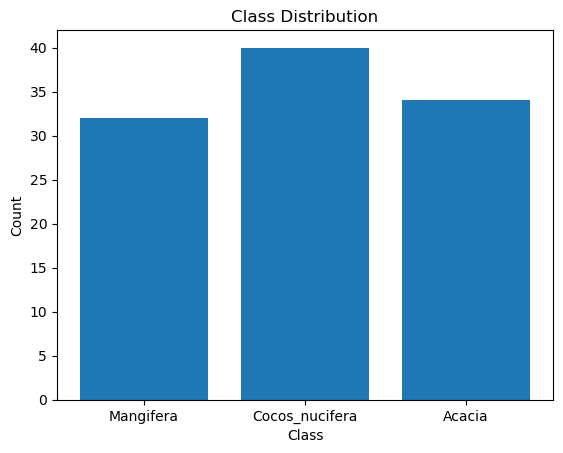

Mangifera: 32 samples (30.19%)
Cocos_nucifera: 40 samples (37.74%)
Acacia: 34 samples (32.08%)


In [37]:
visualize_class_distribution(labels, class_names)

In [39]:
features = np.array([extract_features(img) for img in images ])

In [43]:
X_train, X_test, y_train, y_test = train_test_split(features, labels,test_size = 0.2, random_state = 42)

In [51]:
svm_classifier = SVC(kernel = 'linear')
svm_classifier.fit(X_train,y_train)

SVC(kernel='linear')

In [50]:
rfc = RandomForestClassifier(n_estimators = 100) 
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [61]:
y_pred_svm = svm_classifier.predict(X_test)
y_pred_rfc = rfc.predict(X_test)

In [63]:
accuracy_svm = accuracy_score(y_test,y_pred_svm)
print(f'SVM Accuracy Score: {accuracy_svm * 100 }')

accuracy_rf = accuracy_score(y_test, y_pred_rfc)
print("Random Forest Classifier Accuracy:", accuracy_rf * 100)

SVM Accuracy Score: 95.45454545454545
Random Forest Classifier Accuracy: 63.63636363636363


### Pre processing grayscale and resize

In [67]:
def preprocess_image(image_path, save_path):
    image = cv2.imread(image_path)

    resized_image = cv2.resize(image,(200,266))

    grayscale_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)
    cv2.imwrite(save_path, grayscale_image)
    return grayscale_image

In [73]:
input_image_path = 'test.jpg'
save_path = 'pre_process.jpg'
preprocess_image = preprocess_image(input_image_path, save_path)

TypeError: 'numpy.ndarray' object is not callable